<a href="https://colab.research.google.com/github/kxrrym03/AI-Impact-on-Job-Salaries/blob/main/AI_vs_Job_Salaries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ai_jobs_salaries_clean.csv to ai_jobs_salaries_clean.csv


In [ ]:
df = pd.read_csv('ai_jobs_salaries_clean.csv')
df.shape

(71913, 17)

In [ ]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,isco_group_hint
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M,Executive-level,Full-time,On-site,True,Analytics Manager,Information and communications technology serv...
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M,Executive-level,Full-time,On-site,False,Analytics Manager,Information and communications technology serv...
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M,Mid-level,Full-time,Remote,False,Other / Unclassified,NaN


In [ ]:
df.tail()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,isco_group_hint
71908,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L,Senior-level,Full-time,Remote,True,Data Scientist,"Mathematicians, actuaries and statisticians"
71909,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L,Mid-level,Full-time,Remote,False,Data Scientist,"Mathematicians, actuaries and statisticians"
71910,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S,Entry-level,Full-time,Remote,False,Data Scientist,"Mathematicians, actuaries and statisticians"
71911,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L,Entry-level,Contract,Remote,False,Data Analyst,Business services and administration managers
71912,2021,SE,FT,Data Scientist,7000000,INR,94665,IN,50,IN,L,Senior-level,Full-time,Hybrid,False,Data Scientist,"Mathematicians, actuaries and statisticians"


In [ ]:
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [ ]:
df = df.drop('isco_group_hint', axis=1)
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,71913.000000,7.191300e+04,71913.000000,71913.000000
mean,2024.425153,1.617102e+05,151161.252625,24.569271
std,0.721198,2.872868e+05,77329.594122,42.917779
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,9.640000e+04,96000.000000,0.000000
50%,2025.000000,1.397000e+05,138750.000000,0.000000
75%,2025.000000,1.922000e+05,190315.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71913 entries, 0 to 71912
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   work_year               71913 non-null  int64 
 1   experience_level        71913 non-null  object
 2   employment_type         71913 non-null  object
 3   job_title               71913 non-null  object
 4   salary                  71913 non-null  int64 
 5   salary_currency         71913 non-null  object
 6   salary_in_usd           71913 non-null  int64 
 7   employee_residence      71913 non-null  object
 8   remote_ratio            71913 non-null  int64 
 9   company_location        71913 non-null  object
 10  company_size            71913 non-null  object
 11  experience_level_label  71913 non-null  object
 12  employment_type_label   71913 non-null  object
 13  work_mode               71913 non-null  object
 14  salary_outlier_flag     71913 non-null  bool  
 15  ro

## Data Visualization

### Distribution of Salaries

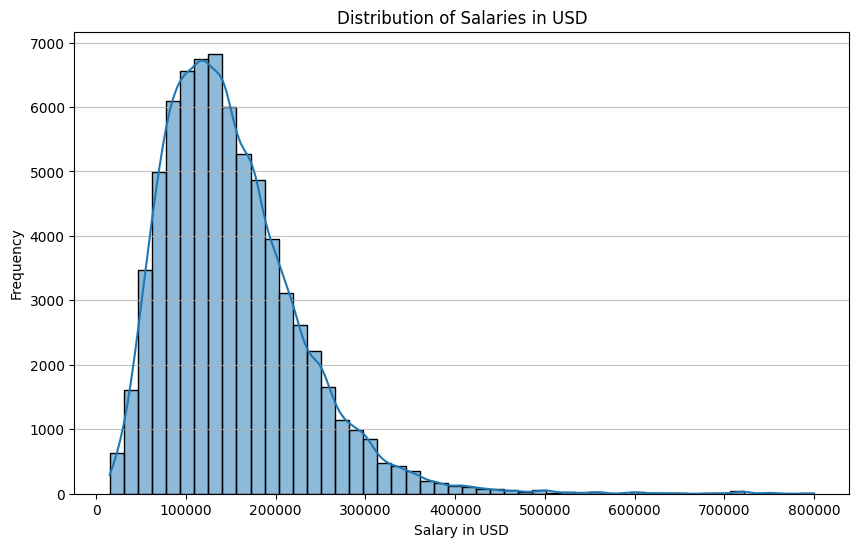

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_in_usd'], bins=50, kde=True)
plt.title('Distribution of Salaries in USD')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Salary vs. Experience Level

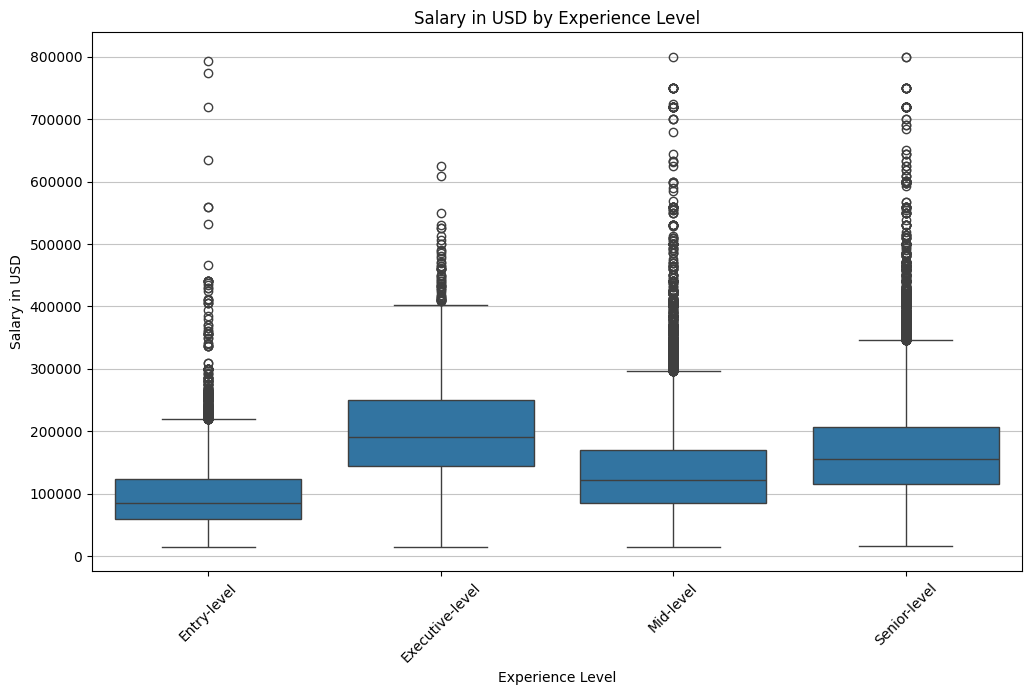

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='experience_level_label', y='salary_in_usd', data=df.sort_values('experience_level_label'))
plt.title('Salary in USD by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary in USD')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.show()

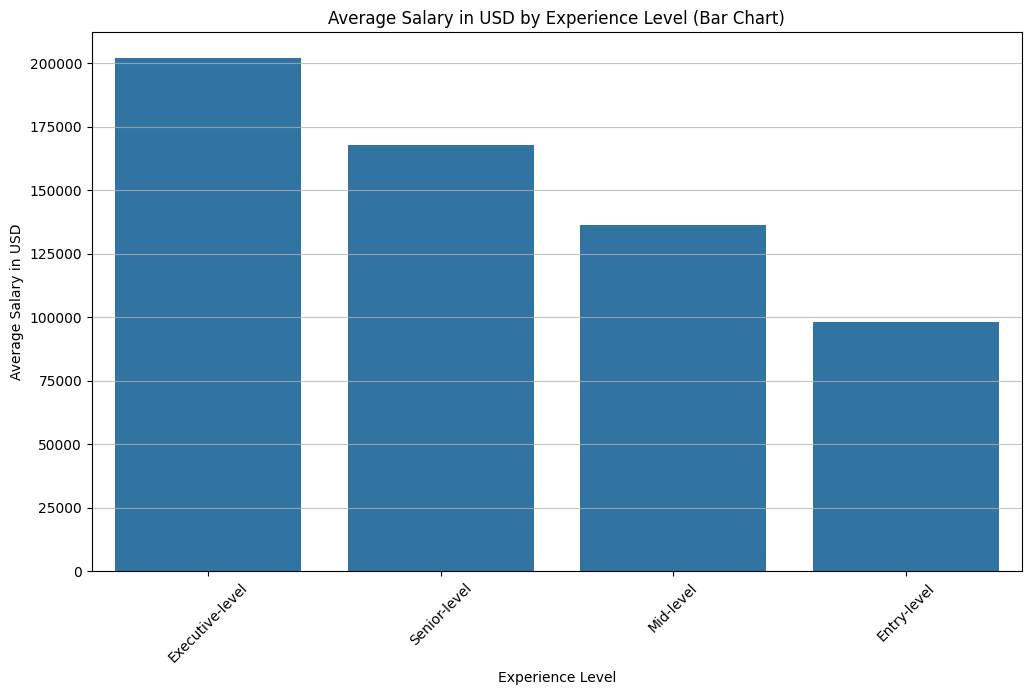

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='experience_level_label', y='salary_in_usd', data=df.groupby('experience_level_label')['salary_in_usd'].mean().reset_index().sort_values('salary_in_usd', ascending=False))
plt.title('Average Salary in USD by Experience Level (Bar Chart)')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary in USD')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.show()

### Salary vs. Top 10 Job Titles

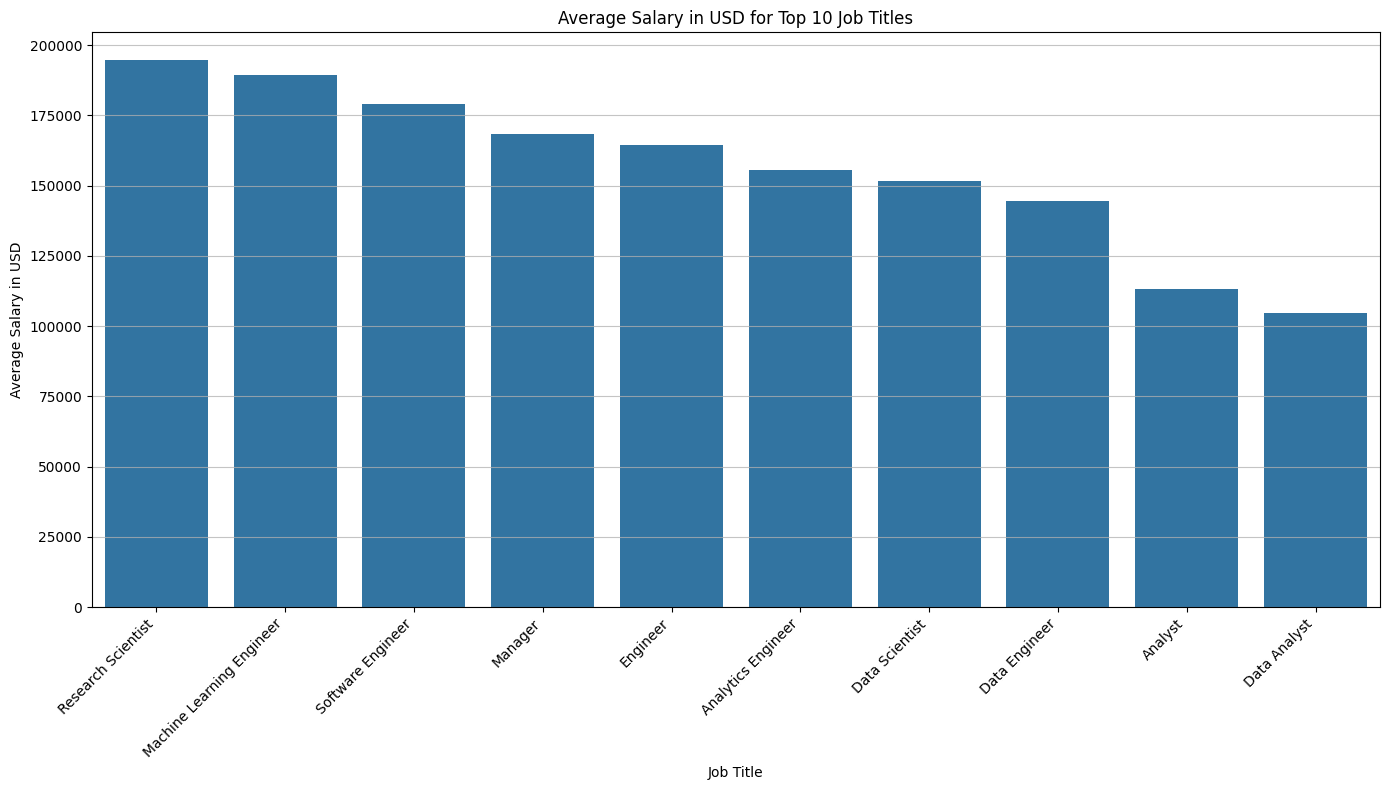

In [ ]:
# Get top 10 job titles
top_10_job_titles = df['job_title'].value_counts().head(10).index
df_top_jobs = df[df['job_title'].isin(top_10_job_titles)]

plt.figure(figsize=(14, 8))
sns.barplot(x='job_title', y='salary_in_usd', data=df_top_jobs.groupby('job_title')['salary_in_usd'].mean().reset_index().sort_values(by='salary_in_usd', ascending=False))
plt.title('Average Salary in USD for Top 10 Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Average Salary in USD')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Salary Trend Over Work Year

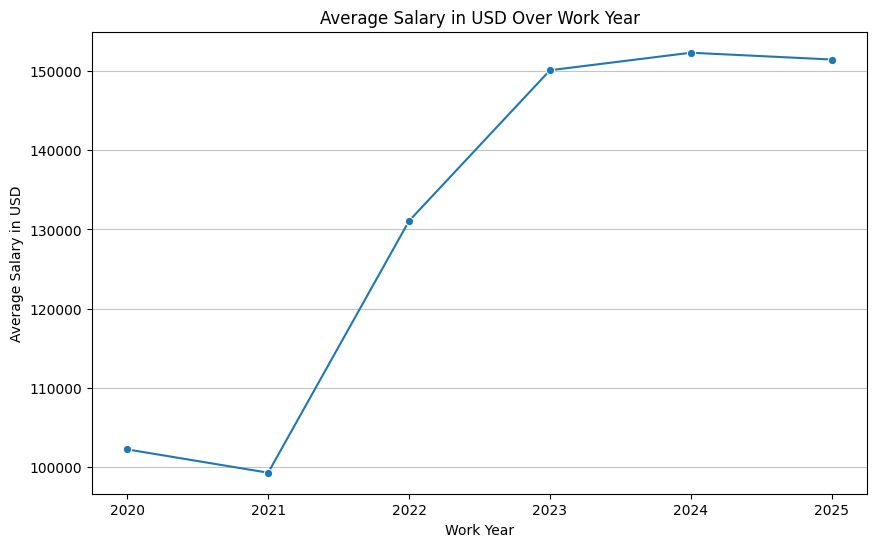

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='work_year', y='salary_in_usd', data=df.groupby('work_year')['salary_in_usd'].mean().reset_index(), marker='o')
plt.title('Average Salary in USD Over Work Year')
plt.xlabel('Work Year')
plt.ylabel('Average Salary in USD')
plt.xticks(sorted(df['work_year'].unique()))
plt.grid(axis='y', alpha=0.75)
plt.show()

### Salary vs. Remote Ratio

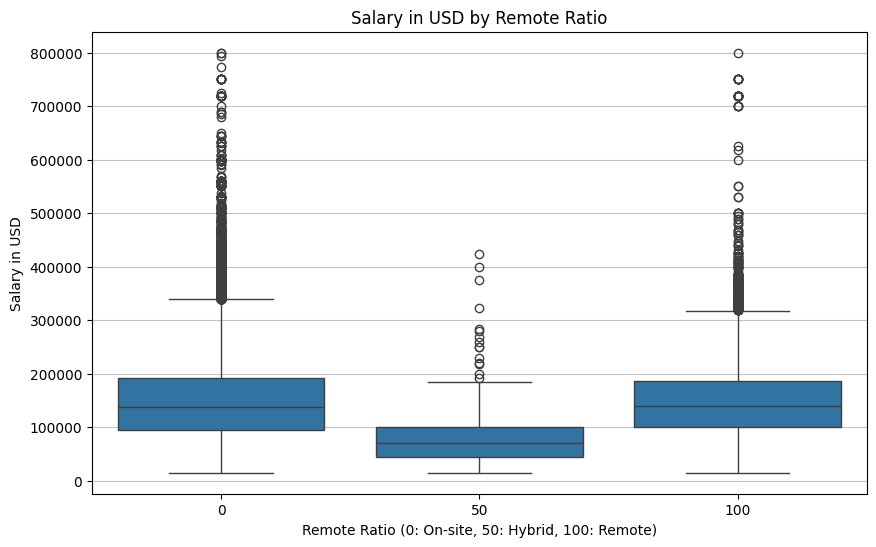

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df)
plt.title('Salary in USD by Remote Ratio')
plt.xlabel('Remote Ratio (0: On-site, 50: Hybrid, 100: Remote)')
plt.ylabel('Salary in USD')
plt.grid(axis='y', alpha=0.75)
plt.show()

## Top 5 Highest-Paying Job Titles

In [ ]:
top_5_job_titles = df.groupby('job_title')['salary_in_usd'].mean().nlargest(5).reset_index()
display(top_5_job_titles)

,job_title,salary_in_usd
0,Research Team Lead,450000.0
1,Analytics Engineering Manager,399880.0
2,Data Science Tech Lead,375000.0
3,Head of Machine Learning,300620.6
4,Applied AI ML Lead,292500.0


## Machine Learning Preparation

### Feature Selection and Encoding

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = df.drop('salary_in_usd', axis=1)
y = df['salary_in_usd']

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object', 'bool']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

print("Features (X) and target (y) defined.")
print(f"Categorical features to encode: {list(categorical_features)}")
print(f"Numerical features: {list(numerical_features)}")

Features (X) and target (y) defined.
Categorical features to encode: ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size', 'experience_level_label', 'employment_type_label', 'work_mode', 'salary_outlier_flag', 'role_family']
Numerical features: ['work_year', 'salary', 'remote_ratio']


### Splitting Data into Training and Testing Sets

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (57530, 15)
X_test shape: (14383, 15)
y_train shape: (57530,)
y_test shape: (14383,)


### Training a Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

# Create a pipeline that first preprocesses the data and then trains a Linear Regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


### Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 49510.16
Mean Squared Error (MSE): 4553752579.37
Root Mean Squared Error (RMSE): 67481.50
R-squared (R2): 0.25


### Trying Other Models: Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create a pipeline with the preprocessor and a RandomForestRegressor
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Train the Random Forest model
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully!")

Random Forest Regressor model trained successfully!


### Random Forest Model Evaluation

In [ ]:
# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest - Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"Random Forest - R-squared (R2): {r2_rf:.2f}")

Random Forest - Mean Absolute Error (MAE): 204.30
Random Forest - Mean Squared Error (MSE): 24265689.74
Random Forest - Root Mean Squared Error (RMSE): 4926.02
Random Forest - R-squared (R2): 1.00
